In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
import h5py
f = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

In [3]:
list(f.keys())

['chi1x',
 'chi1y',
 'chi1z',
 'chi2x',
 'chi2y',
 'chi2z',
 'dec',
 'det',
 'iota',
 'mtot',
 'psi',
 'q',
 'ra',
 'snr',
 'z']

In [4]:
f['det'][::1000]

array([0, 0, 0, ..., 0, 0, 0])

In [5]:
N_slice = 1000

mtot = f['mtot'][::N_slice]
iota = f['iota'][::N_slice]
z = f['z'][::N_slice]

det = f['det'][::N_slice]

X = np.array([mtot, z]).T
y = det

In [6]:
n_featrures = 13
X=[]
for l in ['mtot', 'z', 'dec', 'iota', 'psi', 'q', 'ra', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z']:
    X.append(f[l][::N_slice])
X = np.array(X).T
y = np.array(f['det'][::N_slice])

In [7]:
from astroML.utils import split_samples
from astroML.utils import completeness_contamination


(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)

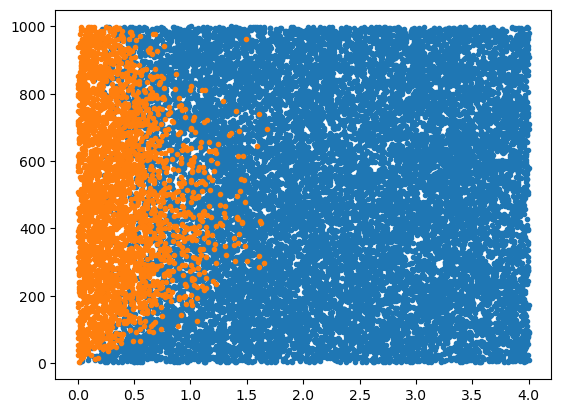

In [8]:
plt.scatter(X[:,1][y==0],X[:,0][y==0],marker='.')
plt.scatter(X[:,1][y==1],X[:,0][y==1],marker='.')


In [9]:
from sklearn.tree import DecisionTreeClassifier


dtree = DecisionTreeClassifier(max_depth=10)
dtree.fit(X_train,y_train)

y_pred = dtree.predict(X_test)
print(dtree.get_depth())
print(dtree.get_n_leaves())

10
245


In [10]:
Ncolors = np.arange(1, X.shape[1] + 1)

classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)
depths = [7, 12]

for depth in depths:
    classifiers.append([])
    predictions.append([])
    for nc in Ncolors:
        clf = DecisionTreeClassifier(random_state=0, max_depth=depth,
                                     criterion='entropy')
        clf.fit(X_train[:, :nc], y_train)
        y_pred = clf.predict(X_test[:, :nc])

        classifiers[-1].append(clf)
        predictions[-1].append(y_pred)

completeness, contamination = completeness_contamination(predictions, y_test)
print("features", Ncolors)
print("completeness", completeness)
print("contamination", contamination)

features [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
completeness [[0.002849   0.76353276 0.78490028 0.85327635 0.83475783 0.81339031
  0.81196581 0.81196581 0.81196581 0.81196581 0.81623932 0.81766382
  0.81481481]
 [0.0042735  0.75356125 0.78347578 0.81908832 0.80626781 0.83333333
  0.82905983 0.82905983 0.81196581 0.84188034 0.83618234 0.84757835
  0.84615385]]
contamination [[0.89473684 0.1424     0.19326501 0.1894452  0.19283747 0.17246377
  0.17630058 0.17630058 0.17271408 0.15805022 0.1622807  0.15835777
  0.16374269]
 [0.92307692 0.17984496 0.22425952 0.2058011  0.20169252 0.18181818
  0.1814346  0.18941504 0.19831224 0.16170213 0.16973126 0.16783217
  0.17728532]]


DecisionTreeClassifier(criterion='entropy', max_depth=12, random_state=0)


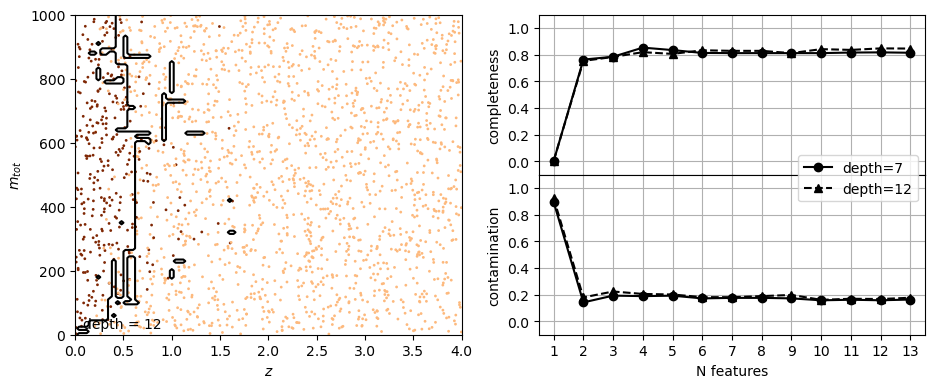

In [11]:
N_plot = 2000

#------------------------------------------------------------
# compute the decision boundary

clf = classifiers[1][1]
print(clf)
xlim = (0., 4.)
ylim = (0., 1e3)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 101),
                     np.linspace(ylim[0], ylim[1], 101))

Z = clf.predict(np.c_[yy.ravel(), xx.ravel()])
Z = Z.reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$z$')
ax.set_ylabel('$m_{tot}$')

ax.text(0.02, 0.02, "depth = %i" % depths[1],
        transform=ax.transAxes)

# plot completeness vs Ncolors
ax = fig.add_subplot(222)
ax.plot(Ncolors, completeness[0], 'o-k', ms=6, label="depth=%i" % depths[0])
ax.plot(Ncolors, completeness[1], '^--k', ms=6, label="depth=%i" % depths[1])

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, n_featrures+0.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination[0], 'o-k', ms=6, label="depth=%i" % depths[0])
ax.plot(Ncolors, contamination[1], '^--k', ms=6, label="depth=%i" % depths[1])
ax.legend(loc='lower right',
          bbox_to_anchor=(1.0, 0.79))

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N features')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, n_featrures+0.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

Best depth
-

In [12]:
from sklearn.model_selection import GridSearchCV

clf = DecisionTreeClassifier()
drange = np.arange(1,21) 

grid = GridSearchCV(clf, param_grid={'max_depth': drange}, cv=5)
grid.fit(X_train, y_train)

best = grid.best_params_['max_depth']
print("best parameter choice:", best)

best parameter choice: 7


In [13]:
DecisionTreeClassifier(random_state=0, max_depth=best, criterion='entropy')

DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=0)

In [14]:
clf = DecisionTreeClassifier(random_state=0, max_depth=best,
                                     criterion='entropy')
clf.fit(X_train[:, :], y_train)
y_pred = clf.predict(X_test[:, :])

In [15]:
completeness, contamination = completeness_contamination(y_pred, y_test)
print("completeness", completeness)
print("contamination", contamination)

completeness 0.8148148148148148
contamination 0.16374269005847952


In [17]:
from sklearn.metrics import confusion_matrix

y_pred = clf.predict(X_test)
C = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = C.ravel()
print("completeness test", tp/(tp+fn))
print("contamination test", fp/(tp+fp))

y_pred_tr = clf.predict(X_train)
C = confusion_matrix(y_train, y_pred_tr)
tn, fp, fn, tp = C.ravel()
print("completeness train", tp/(tp+fn))
print("contamination train", fp/(tp+fp))

print("fraction of correct classifications in test", (tp+tn)/(tp+fp+tn+fn))

completeness test 0.8148148148148148
contamination test 0.16374269005847952
completeness train 0.8370004490345757
contamination train 0.10125361620057859
fraction of correct classifications in test 0.9618


In [19]:
clf.fit(X_train[:, :2], y_train)
y_pred = clf.predict(X_test[:, :2])

dt = DecisionTreeClassifier(random_state=0, max_depth=best, 
                            criterion='entropy')
dt.fit(X_train, y_train)
yprob = dt.predict_proba(X_test) # If we wanted probabilities rather than the discrete classes

xlim = (0., 4.)
ylim = (0., 1e3)



xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 101),
                     np.linspace(ylim[0], ylim[1], 101))

Z = clf.predict(np.c_[yy.ravel(), xx.ravel()])
Z = Z.reshape(xx.shape)

Text(0.02, 0.02, 'depth = 7')

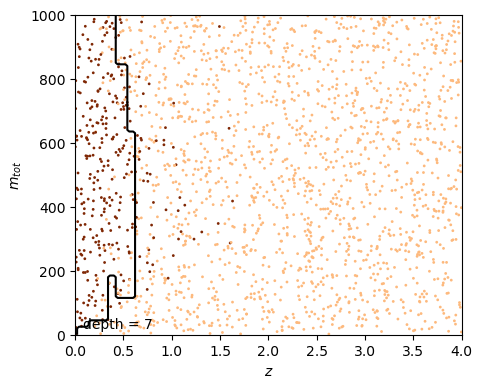

In [20]:

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$z$')
ax.set_ylabel('$m_{tot}$')

ax.text(0.02, 0.02, "depth = %i" % best,
        transform=ax.transAxes)


In [22]:
from sklearn.metrics import roc_curve

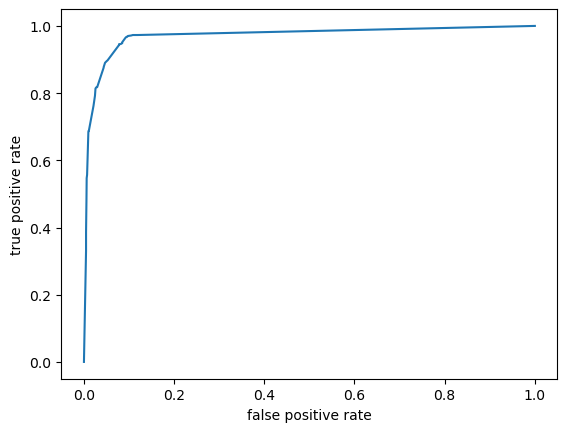

In [26]:
classifiers = []
predictions = []



clf = DecisionTreeClassifier(random_state=0, max_depth=best,criterion='entropy')
clf.fit(X_train[:, :], y_train)
y_pred = clf.predict(X_test[:, :])
y_prob = (clf.predict_proba(X_test[:, :])[:,1])

classifiers.append(clf)
predictions.append(y_pred)

y_prob = clf.predict_proba(X_test[:,:]) [:,1] 

fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
    
plt.xlabel('false positive rate')
plt.ylabel('true positive rate');

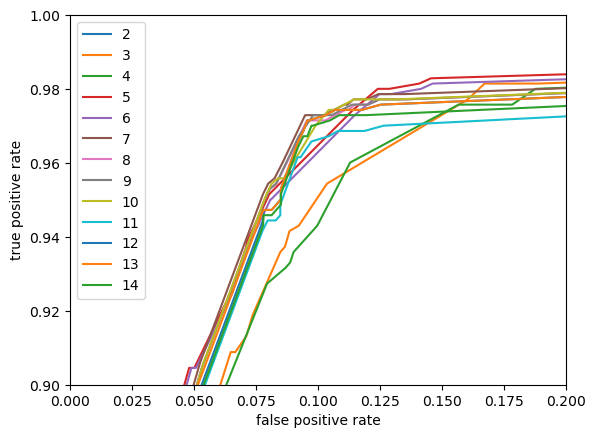

In [24]:
classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)


for nc in Ncolors:
    clf = DecisionTreeClassifier(random_state=0, max_depth=best,criterion='entropy')
    clf.fit(X_train[:, :nc], y_train)
    y_pred = clf.predict(X_test[:, :nc])

    classifiers.append(clf)
    predictions.append(y_pred)
    
    y_prob = clf.predict_proba(X_test[:,:nc]) [:,1] 
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(nc+1))
    
plt.legend()
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')

plt.xlim(0,0.2)
plt.ylim(0.9,1);

In [25]:
completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness [0.002849   0.76353276 0.78490028 0.85327635 0.83475783 0.81339031
 0.81196581 0.81196581 0.81196581 0.81196581 0.81623932 0.81766382
 0.81481481]
contamination [0.89473684 0.1424     0.19326501 0.1894452  0.19283747 0.17246377
 0.17630058 0.17630058 0.17271408 0.15805022 0.1622807  0.15835777
 0.16374269]
